# Tech Challenge - Fase 5: EDA do IBOV

Análise exploratória da série histórica do Ibovespa que alimenta o pipeline LSTM. O escopo enxuto. Cobrimos:

1. **Distribuições** — preço, retornos, volatilidade.
2. **Sazonalidade** — efeitos de calendário (dia da semana, mês, ano).
3. **Dependência temporal** — autocorrelação, estacionariedade.
4. **Insights de feature engineering** — justificativa para as escolhas em [`src/ibov_pipeline/feature_engineering.py`](../src/ibov_pipeline/feature_engineering.py).

A coleta usa o mesmo módulo do pipeline ([`make_dataset.py`](../src/ibov_pipeline/make_dataset.py)) — se o CSV já existe em `data/raw/ibov/`, ele é lido; caso contrário, é baixado via yfinance e validado com `pandera`. Isso garante que o EDA inspeciona **exatamente os mesmos bytes** que o treino consumirá.

## 0. Bootstrap

In [2]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

os.environ["MODEL_CONFIG_PATH"] = str(PROJECT_ROOT / "src" /"ibov_pipeline" /"configs" / "model_config.yaml")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.ibov_pipeline.config import cfg
from src.ibov_pipeline import make_dataset as md

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print(f"Símbolo        : {cfg.data.symbol}")
print(f"Período        : {cfg.data.start_date} → {cfg.data.end_date or 'hoje'}")
print(f"CSV bruto      : {cfg.data.raw_path}")
print(f"Time step LSTM : {cfg.features.time_step} pregões")

Símbolo        : ^BVSP
Período        : 2019-01-01 → 2026-04-30
CSV bruto      : data/raw/ibov/ibov_close.csv
Time step LSTM : 60 pregões


## 1. Carregamento e visão geral

`md.run()` baixa do yfinance na primeira execução e cacheia em `data/raw/ibov/ibov_close.csv`. As execuções seguintes apenas lêem do disco.

In [3]:
df = md.run()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

print(f"Registros : {len(df):,}")
print(f"Período   : {df.index.min().date()} → {df.index.max().date()}")
print(f"Colunas   : {list(df.columns)}")
print(f"Nulos     : {df['Close'].isna().sum()}")
print(f"\nDescritivas (Close):")
df['Close'].describe().to_frame().T

Registros : 1,822
Período   : 2019-01-02 → 2026-04-29
Colunas   : ['Close']
Nulos     : 0

Descritivas (Close):


,count,mean,std,min,25%,50%,75%,max
Close,"1,822.0000","118,182.0121","20,704.2716","63,570.0000","104,468.7500","115,736.5000","127,668.7500","198,657.0000"


## 2. Série histórica e volatilidade rolante

Linha azul = preço de fechamento; linha laranja = média móvel de 60 pregões (= `cfg.features.time_step`); banda cinza = ±1σ rolante. A janela de 60 é a mesma usada pelo LSTM como lookback.

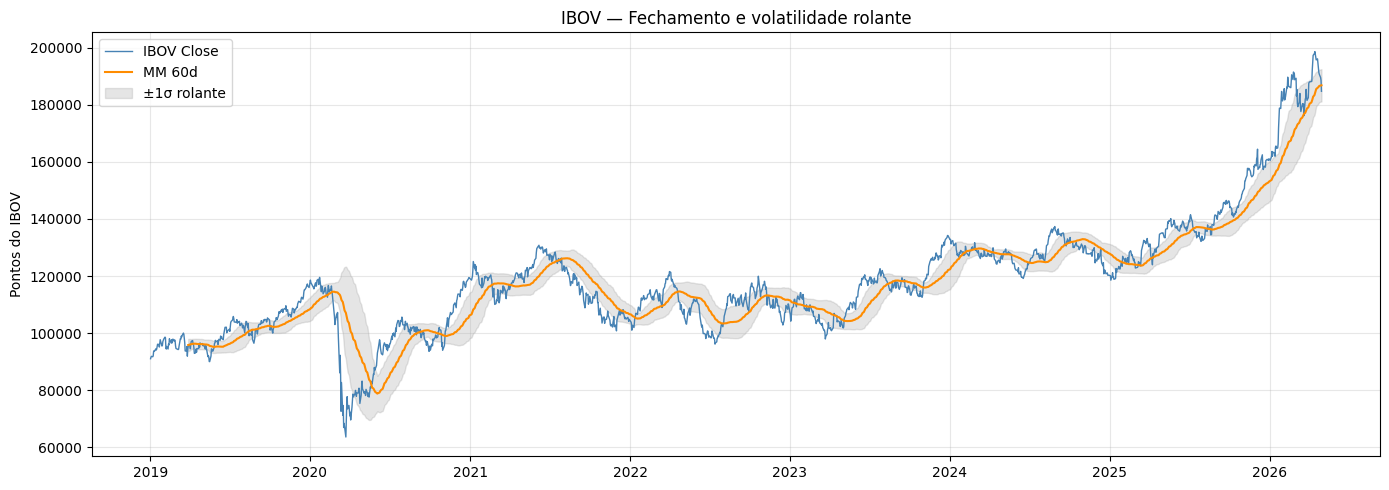

In [4]:
window = cfg.features.time_step
rolling_mean = df['Close'].rolling(window).mean()
rolling_std = df['Close'].rolling(window).std()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['Close'], color='steelblue', label='IBOV Close', linewidth=1)
ax.plot(df.index, rolling_mean, color='darkorange', label=f'MM {window}d', linewidth=1.5)
ax.fill_between(
    df.index,
    rolling_mean - rolling_std,
    rolling_mean + rolling_std,
    color='gray', alpha=0.2, label='±1σ rolante',
)
ax.set_title('IBOV — Fechamento e volatilidade rolante')
ax.set_ylabel('Pontos do IBOV')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Distribuição de preços vs. retornos

Preço é tipicamente **não-estacionário** (média e variância mudam ao longo do tempo); retornos diários são razoavelmente estacionários e quase-normais com caudas pesadas. Isso motiva tanto a normalização do LSTM quanto a discussão de mudar o alvo para retorno em iterações futuras.

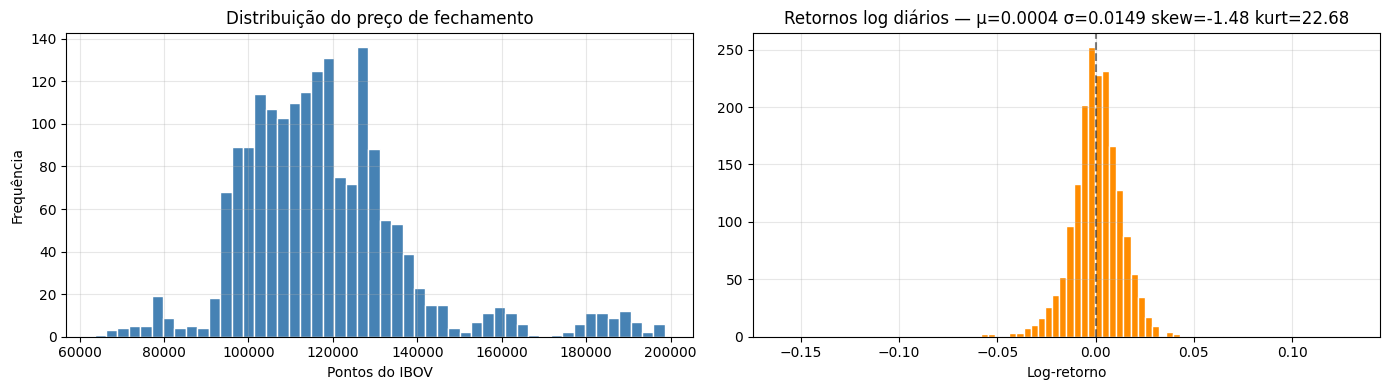

In [5]:
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Close'].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição do preço de fechamento')
axes[0].set_xlabel('Pontos do IBOV')
axes[0].set_ylabel('Frequência')
axes[0].grid(alpha=0.3)

ret = df['log_return'].dropna()
axes[1].hist(ret, bins=80, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title(
    f'Retornos log diários — μ={ret.mean():.4f} σ={ret.std():.4f} '
    f'skew={ret.skew():.2f} kurt={ret.kurt():.2f}'
)
axes[1].set_xlabel('Log-retorno')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Sazonalidade — efeitos de calendário

Três cortes clássicos: dia da semana, mês do ano, e heatmap ano × mês. Para o IBOV em janelas curtas, esses efeitos são em geral pequenos e ruidosos — confirmá-lo evita gastar capacidade do modelo em features sazonais que não pagariam o custo.

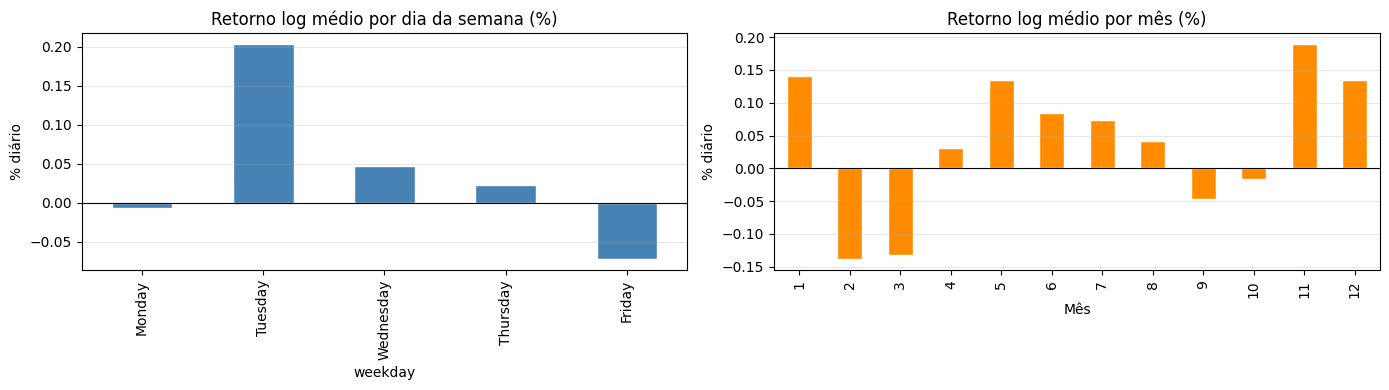

In [6]:
df['weekday'] = df.index.day_name()
df['month'] = df.index.month
df['year'] = df.index.year

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
by_wday = df.groupby('weekday')['log_return'].mean().reindex(weekday_order) * 100
by_wday.plot.bar(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Retorno log médio por dia da semana (%)')
axes[0].set_ylabel('% diário')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].grid(alpha=0.3, axis='y')

by_month = df.groupby('month')['log_return'].mean() * 100
by_month.plot.bar(ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Retorno log médio por mês (%)')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('% diário')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

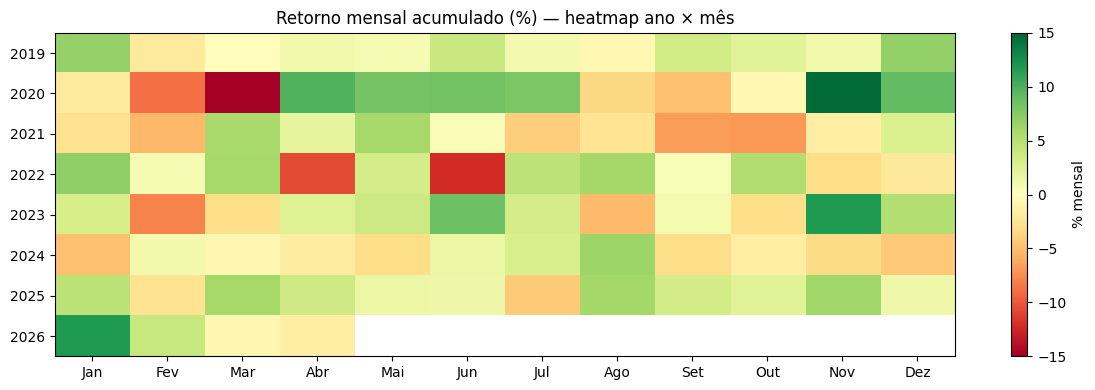

In [6]:
monthly_ret = (
    df.groupby(['year', 'month'])['log_return']
      .sum()
      .unstack('month') * 100
)

fig, ax = plt.subplots(figsize=(12, max(4, 0.35 * len(monthly_ret))))
im = ax.imshow(monthly_ret.values, cmap='RdYlGn', aspect='auto', vmin=-15, vmax=15)
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                    'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
ax.set_yticks(range(len(monthly_ret.index)))
ax.set_yticklabels(monthly_ret.index)
ax.set_title('Retorno mensal acumulado (%) — heatmap ano × mês')
plt.colorbar(im, ax=ax, label='% mensal')
plt.tight_layout()
plt.show()

## 5. Autocorrelação — quanto o passado prevê o futuro?

Comparamos a ACF do **preço** (esperada perto de 1 — não-estacionário) com a ACF dos **retornos** (esperada perto de 0 — random walk). A queda abrupta da segunda confirma a hipótese de mercado eficiente em horizonte diário e baliza a expectativa realista para a acurácia direcional do LSTM.

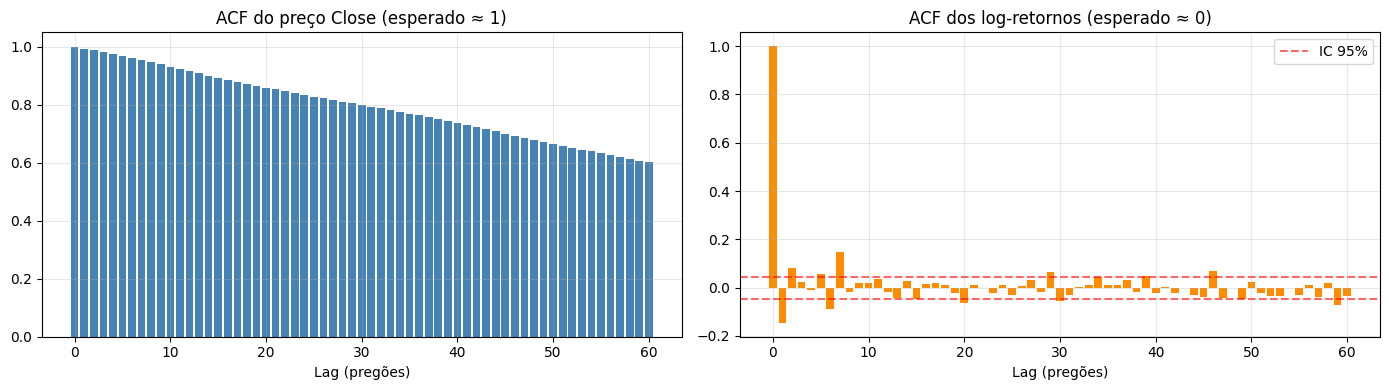

In [14]:
def acf(series: pd.Series, n_lags: int = 30) -> np.ndarray:
    s = series.dropna().values
    s = s - s.mean()
    var = (s ** 2).sum()
    return np.array([
        ((s[:-k] * s[k:]).sum() / var) if k > 0 else 1.0
        for k in range(n_lags + 1)
    ])

n_lags = 60
acf_price = acf(df['Close'], n_lags)
acf_return = acf(df['log_return'], n_lags)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(n_lags + 1), acf_price, color='steelblue')
axes[0].set_title('ACF do preço Close (esperado ≈ 1)')
axes[0].set_xlabel('Lag (pregões)')
axes[0].grid(alpha=0.3)

ci = 1.96 / np.sqrt(len(df['log_return'].dropna()))
axes[1].bar(range(n_lags + 1), acf_return, color='darkorange')
axes[1].axhline(ci, color='red', linestyle='--', alpha=0.6, label='IC 95%')
axes[1].axhline(-ci, color='red', linestyle='--', alpha=0.6)
axes[1].set_title('ACF dos log-retornos (esperado ≈ 0)')
axes[1].set_xlabel('Lag (pregões)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Estacionariedade (ADF)

Confirmação numérica do que a ACF acima sugere visualmente. Esperado: preço **não rejeita** a hipótese nula (raiz unitária presente, série não-estacionária); retornos **rejeitam** (estacionários).


In [13]:
try:
    from statsmodels.tsa.stattools import adfuller
    from IPython.display import display # Garante a exibição formatada no Jupyter

    def adf_summary(series: pd.Series, label: str) -> dict:
        # Executa o teste ADF. O 'AIC' escolhe automaticamente o melhor número de lags
        stat, pvalue, *_ = adfuller(series.dropna(), autolag='AIC')
        
        return {
            'Série': label,
            'Estatística ADF': round(stat, 4),
            'P-Valor': round(pvalue, 6), # Mantém algumas casas a mais para p-valores muito pequenos
            'Estacionária? (α=0.05)': 'Sim' if pvalue < 0.05 else 'Não'
        }

    # Gera o DataFrame com os resultados
    df_adf = pd.DataFrame([
        adf_summary(df['Close'], 'Preço (Close)'),
        adf_summary(df['log_return'], 'Log-retorno'),
    ])
    
    # Exibe o resultado final
    print("--- Resultado do Teste de Dickey-Fuller Aumentado (ADF) ---")
    display(df_adf)

except ImportError:
    print("statsmodels não instalado — pulando ADF. "
          "Instale com `pip install statsmodels` se precisar do teste numérico.")

--- Resultado do Teste de Dickey-Fuller Aumentado (ADF) ---


,Série,Estatística ADF,P-Valor,Estacionária? (α=0.05)
0,Preço (Close),-0.5476,0.8824,Não
1,Log-retorno,-14.3775,0.0000,Sim


## 7. Insights → decisões em `feature_engineering.py`

O que a EDA acima informa:

| Observação na EDA | Decisão em [`feature_engineering.py`](../src/ibov_pipeline/feature_engineering.py) | Justificativa |
|---|---|---|
| Preço não-estacionário, escala muda ao longo do período | `MinMaxScaler(feature_range=[0,1])` | Estabiliza a entrada para LSTM sem destruir a forma da série |
| Volatilidade rolante 60d captura regimes (ex: COVID, eleições) | `time_step = 60` | Lookback alinhado ao horizonte natural de variação do regime |
| ACF do preço ≈ 1 (memória longa) | Alvo é o preço de t+1 (não retorno) | Aproveita a auto-similaridade local do preço |
| ACF do retorno ≈ 0 | Acurácia direcional ~50% é esperada | Documentado como limitação no [`MODEL_CARD_IBOV.md`](../docs/MODEL_CARD_IBOV.md) |
| Anomalia de retornos (Alta às terças / Queda às sextas e segundas) | Sem feature de calendário na v0 | Mantém o baseline inicial simples e evita aumentar a dimensionalidade antes de validar a arquitetura base |
| Distribuição de retornos com caudas pesadas | EarlyStopping + dropout no LSTM | Reduz risco de fit a outliers de crash/rali |

### Próximas iterações sugeridas (fora do escopo do datathon, registradas no Model Card)

- **Trocar alvo para log-retorno** — pode quebrar o efeito de *lag* visual sem prejudicar MAPE depois de re-escalado.
- **Features exógenas** — Dólar futuro, S&P500 com defasagem de 1 dia, taxa Selic. Candidatas óbvias dado que IBOV é fortemente correlacionado a fluxo internacional.
- **Indicadores técnicos** — RSI, MACD como features adicionais ao Close.
- **Features de calendário (Sazonalidade)** — incluir dias da semana codificados via *One-Hot Encoding* para permitir que o modelo capture matematicamente o prêmio de risco das terças-feiras (*Turnaround Tuesday*) e a aversão a risco dos finais de semana.
- **Quebra estrutural** — testar Chow/Bai-Perron para detectar regimes e treinar modelos por regime.